In [10]:
!pip install folium
!pip install pulp

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1 -> 26.1.2
[notice] To update, run: C:\Users\Huy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 5.0 MB/s eta 0:00:04
   --- ------------------------------------ 1.6/16.4 MB 5.1 MB/s eta 0:00:03
   ------- -------------------------------- 2.9/16.4 MB 5.6 MB/s eta 0:00:03
   ---------- ----------------------------- 4.2/16.4 MB 5.8 MB/s eta 0:00:03
   ------------ --------------------------- 5.2/16.4 MB 5.7 MB/s eta 0:00:02
   ---------------- ----------------------- 6.8/16.4 MB 5.8 MB/s eta 0:00:02
   ------------------- -------------------- 8.1/16.4 MB 5.9 MB/s eta 0:00:02
   ----------------------- ---------------- 9.4/16.4 MB 6.0 MB/s eta 0:00:02
   -------------------------- ------------- 10.7/16.4 MB 6.0 MB/s eta 0:00:01
   ---------------------------- ----------- 11.8/16.4 MB 6.1 MB/s eta 0:00:01
   ------------------------------- -------- 12.8/16.4 MB 5.8 MB/s eta 0:00:01
  


[notice] A new release of pip is available: 25.1 -> 26.1.2
[notice] To update, run: C:\Users\Huy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2
import pulp
import matplotlib.pyplot as plt
import folium
from IPython.display import display

### 1.Creating and Processing Data

In [ ]:
# =========================
# 1. KHỞI TẠO DỮ LIỆU MẪU (MULTI-PRODUCT TẠI TP.HCM)
# =========================
np.random.seed(42)

# Tâm bản đồ: Thành phố Hồ Chí Minh (Khu vực Quận 1)
HCMC_LAT = 10.7769
HCMC_LON = 106.7009

# Quy mô bài toán
num_clients = 150
num_depots = 40

# Các tham số vận hành
MAX_COVERAGE_RADIUS_KM = 4.5
TRANSPORT_COST_PER_KM = 0.01
MIN_CAPACITY_USAGE = 0.35  # Tỷ lệ sử dụng công suất tối thiểu (Min Capacity)

PRODUCT_TYPES = ["Dry", "Cold"]

# Dữ liệu khách hàng (Clients)
client_df = pd.DataFrame({
    "client_id": [f"C{i+1}" for i in range(num_clients)],
    "lat": HCMC_LAT + np.random.uniform(-0.035, 0.035, num_clients),
    "lon": HCMC_LON + np.random.uniform(-0.045, 0.045, num_clients),
    "demand_Dry": np.random.randint(1, 6, num_clients),
    "demand_Cold": np.random.randint(0, 4, num_clients)
})

# Dữ liệu trạm trung chuyển / kho (Depots)
depot_df = pd.DataFrame({
    "depot_id": [f"D{j+1}" for j in range(num_depots)],
    "lat": HCMC_LAT + np.random.uniform(-0.035, 0.035, num_depots),
    "lon": HCMC_LON + np.random.uniform(-0.045, 0.045, num_depots),
    "capacity_Dry": np.random.randint(40, 100, num_depots),
    "capacity_Cold": np.random.randint(20, 60, num_depots),
    "fixed_cost": np.random.randint(100, 250, num_depots)
})

### 2. DISTANCE FUNCTION

In [7]:
# =========================
# 2. HÀM TÍNH KHOẢNG CÁCH TỌA ĐỘ
# =========================
def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    """
    Tính khoảng cách đường chim bay giữa 2 tọa độ GPS (theo đơn vị km).
    """
    EARTH_RADIUS_KM = 6371.0

    # Chuyển đổi tọa độ độ sang radian
    lat1_rad, lon1_rad, lat2_rad, lon2_rad = map(radians, [lat1, lon1, lat2, lon2])

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    # Áp dụng công thức Haversine
    a = sin(delta_lat / 2)**2 + cos(lat1_rad) * cos(lat2_rad) * sin(delta_lon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return EARTH_RADIUS_KM * c

### 3.SETTING UP DISTANCE AND COVERAGE MATRIX

In [ ]:
# =========================
# 3. THIẾT LẬP MA TRẬN KHOẢNG CÁCH VÀ ĐỘ PHỦ
# =========================
clients_idx = list(client_df.index)
depots_idx = list(depot_df.index)

dist_matrix = {}
coverage_matrix = {}

for i in clients_idx:
    for j in depots_idx:
        dist = calculate_haversine_distance(
            client_df.loc[i, "lat"], client_df.loc[i, "lon"],
            depot_df.loc[j, "lat"], depot_df.loc[j, "lon"]
        )
        
        dist_matrix[i, j] = dist
        # Ma trận nhị phân: 1 nếu trong bán kính phục vụ, 0 nếu nằm ngoài
        coverage_matrix[i, j] = 1 if dist <= MAX_COVERAGE_RADIUS_KM else 0

# Kiểm tra ngoại lệ: Khách hàng ngoại (Không thuộc vùng phủ sóng của bất kỳ kho nào)
unserved_clients = []

for i in clients_idx:
    if sum(coverage_matrix[i, j] for j in depots_idx) == 0:
        unserved_clients.append(client_df.loc[i, "client_id"])

if unserved_clients:
    raise ValueError(
        f"Cảnh báo: Có {len(unserved_clients)} khách hàng không thuộc vùng hỗ trợ của bất kỳ kho nào. "
        f"Vui lòng mở rộng MAX_COVERAGE_RADIUS_KM (hiện tại là {MAX_COVERAGE_RADIUS_KM} km)."
    )

### 4. BUILDING THE MC-CFLP MODEL

In [12]:
# Khởi tạo bài toán tối thiểu hóa chi phí
model = pulp.LpProblem("MC_CFLP_Network_Design", pulp.LpMinimize)

# Biến quyết định y_j: Mở trạm/kho j hay không (0 hoặc 1)
y = pulp.LpVariable.dicts(
    "Open_Depot",
    depots_idx,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

# Biến quyết định x_ijp: Lượng hàng hóa loại p giao từ trạm j cho khách hàng i
# Lưu ý: Chuyển sang biến Continuous (Liên tục) vì đây là số lượng sản phẩm
x = pulp.LpVariable.dicts(
    "Flow",
    (clients_idx, depots_idx, PRODUCT_TYPES),
    lowBound=0,
    cat="Continuous"
)

### 5. OBJECTIVE FUNCTION

In [13]:
# Tổng chi phí = Chi phí cố định mở trạm + Chi phí vận chuyển biến đổi
fixed_costs = pulp.lpSum(
    depot_df.loc[j, "fixed_cost"] * y[j] 
    for j in depots_idx
)

transport_costs = TRANSPORT_COST_PER_KM * pulp.lpSum(
    x[i][j][p] * dist_matrix[i, j]
    for i in clients_idx 
    for j in depots_idx 
    for p in PRODUCT_TYPES
)

model += fixed_costs + transport_costs, "Total_Cost"

### 6. Setting Constraints

In [14]:
# 6.1. Ràng buộc đáp ứng nhu cầu (Demand Fulfillment)
# Mọi khách hàng đều phải được nhận đủ số lượng hàng cho TỪNG loại sản phẩm
for i in clients_idx:
    for p in PRODUCT_TYPES:
        demand_col = f"demand_{p}"
        client_demand = client_df.loc[i, demand_col]
        
        model += (
            pulp.lpSum(x[i][j][p] for j in depots_idx) == client_demand,
            f"Fulfill_Demand_{i}_{p}"
        )

# 6.2. Ràng buộc về vùng phủ và trạng thái mở kho (Coverage & Open Status)
# Lượng hàng giao (x) chỉ > 0 nếu: 1. Khách nằm trong bán kính (coverage=1), 2. Kho được mở (y=1)
for i in clients_idx:
    for j in depots_idx:
        for p in PRODUCT_TYPES:
            demand_col = f"demand_{p}"
            client_demand = client_df.loc[i, demand_col]
            
            # Nếu coverage_matrix[i, j] = 0, toàn bộ vế phải = 0 -> x bắt buộc = 0
            model += (
                x[i][j][p] <= client_demand * coverage_matrix[i, j] * y[j],
                f"Coverage_Logic_{i}_{j}_{p}"
            )

# 6.3. Ràng buộc công suất tối đa (Max Capacity Constraint)
# Tổng lượng hàng loại p xuất ra từ kho j không được vượt quá sức chứa loại p của kho đó
for j in depots_idx:
    for p in PRODUCT_TYPES:
        capacity_col = f"capacity_{p}"
        max_cap = depot_df.loc[j, capacity_col]
        
        model += (
            pulp.lpSum(x[i][j][p] for i in clients_idx) <= max_cap * y[j],
            f"Max_Capacity_{j}_{p}"
        )

# 6.4. Ràng buộc hiệu suất tối thiểu (Minimum Utilization Constraint)
# Tránh việc mở rải rác: Nếu kho j mở (y=1), TỔNG lượng hàng xử lý phải đạt ít nhất MIN_CAPACITY_USAGE
for j in depots_idx:
    total_max_capacity = depot_df.loc[j, "capacity_Dry"] + depot_df.loc[j, "capacity_Cold"]
    
    model += (
        pulp.lpSum(x[i][j][p] for i in clients_idx for p in PRODUCT_TYPES) >= MIN_CAPACITY_USAGE * total_max_capacity * y[j],
        f"Min_Utilization_{j}"
    )

### 7. Model Solving

In [24]:
solver = pulp.PULP_CBC_CMD(msg=False)
model.solve(solver)

print("Trạng thái nghiệm:", pulp.LpStatus[model.status])
print("Giá trị hàm mục tiêu (Tổng chi phí):", round(pulp.value(model.objective), 2))

if pulp.LpStatus[model.status] != "Optimal":
    raise ValueError(
        "Mô hình không tìm được nghiệm tối ưu. "
        "Hãy thử: Nới lỏng Min_Utilization (giảm xuống 0.2), "
        "tăng bán kính phục vụ, hoặc tăng sức chứa của các kho."
    )

Trạng thái nghiệm: Optimal
Giá trị hàm mục tiêu (Tổng chi phí): 734.64


### 8. OPTIMIZE THE RESULT (MULTI-PRODUCT)

In [26]:
open_depots = [j for j in depots_idx if pulp.value(y[j]) > 0.5]
closed_depots = [j for j in depots_idx if pulp.value(y[j]) <= 0.5]

assignments = []

# Trích xuất luồng hàng hóa (Continuous Flow)
for i in clients_idx:
    for j in open_depots:
        for p in PRODUCT_TYPES:
            flow_value = pulp.value(x[i][j][p])
            
            # Chỉ lấy các luồng có giá trị thực tế (tránh sai số dấu phẩy động của Solver)
            if flow_value is not None and flow_value > 0.001:
                assignments.append({
                    "client_index": i,
                    "depot_index": j,
                    "client_id": client_df.loc[i, "client_id"],
                    "depot_id": depot_df.loc[j, "depot_id"],
                    "product_type": p,
                    "flow": round(flow_value, 2),
                    "distance_km": dist_matrix[i, j]
                })

assignments_df = pd.DataFrame(assignments)

depot_summary = []

# Tổng hợp dữ liệu cho từng kho được mở
for j in open_depots:
    d_id = depot_df.loc[j, "depot_id"]
    temp = assignments_df[assignments_df["depot_id"] == d_id]
    
    used_dry = temp[temp["product_type"] == "Dry"]["flow"].sum()
    used_cold = temp[temp["product_type"] == "Cold"]["flow"].sum()
    total_used = used_dry + used_cold
    
    cap_dry = depot_df.loc[j, "capacity_Dry"]
    cap_cold = depot_df.loc[j, "capacity_Cold"]
    total_cap = cap_dry + cap_cold
    
    depot_summary.append({
        "depot_index": j,
        "depot_id": d_id,
        "capacity_Dry": cap_dry,
        "capacity_Cold": cap_cold,
        "total_capacity": total_cap,
        "used_Dry": used_dry,
        "used_Cold": used_cold,
        "total_used": total_used,
        "utilization_rate": total_used / total_cap if total_cap > 0 else 0,
        "num_clients_served": temp["client_id"].nunique(),
        "fixed_cost": depot_df.loc[j, "fixed_cost"]
    })

depot_summary_df = pd.DataFrame(depot_summary)
depot_summary_df = depot_summary_df.sort_values(by="total_used", ascending=False).reset_index(drop=True)

print(f"\nSố trạm tiềm năng để mở: {num_depots}")
print(f"Số trạm ĐƯỢC PHÉP MỞ: {len(open_depots)}")
print(f"Tổng số khách hàng: {num_clients}")
display(depot_summary_df)


Số trạm tiềm năng để mở: 40
Số trạm ĐƯỢC PHÉP MỞ: 6
Tổng số khách hàng: 150


,depot_index,depot_id,capacity_Dry,capacity_Cold,total_capacity,used_Dry,used_Cold,total_used,utilization_rate,num_clients_served,fixed_cost
0,9,D10,94,51,145,94.0,37.0,131.0,0.903448,34,155
1,21,D22,99,25,124,99.0,25.0,124.0,1.000000,31,138
2,11,D12,90,46,136,85.0,27.0,112.0,0.823529,32,106
3,39,D40,55,54,109,55.0,54.0,109.0,1.000000,30,107
4,12,D13,56,48,104,56.0,37.0,93.0,0.894231,23,102
5,8,D9,69,22,91,69.0,22.0,91.0,1.000000,26,113


### 9.DISPLAY RESULTS MAP WITH FOLIUM (HO CHI MINH CITY)

In [ ]:
m = folium.Map(
    location=[HCMC_LAT, HCMC_LON],
    zoom_start=13,
    tiles="CartoDB positron" # Đổi nền sáng để dễ nhìn marker hơn
)

colors = [
    "blue", "green", "purple", "orange", "darkred",
    "cadetblue", "darkgreen", "darkblue", "pink",
    "gray", "black", "lightblue"
]

depot_color = {j: colors[idx % len(colors)] for idx, j in enumerate(open_depots)}

# 9.1. Vẽ vùng phủ và Marker cho các kho ĐƯỢC CHỌN
for j in open_depots:
    row_summary = depot_summary_df[depot_summary_df["depot_index"] == j].iloc[0]
    
    # Vùng phủ
    folium.Circle(
        location=[depot_df.loc[j, "lat"], depot_df.loc[j, "lon"]],
        radius=MAX_COVERAGE_RADIUS_KM * 1000,
        color=depot_color[j], fill=True, fill_opacity=0.05, opacity=0.3,
        popup=f"Vùng phủ của {row_summary['depot_id']}"
    ).add_to(m)

    popup_text = f"""
    <b>Kho mở: {row_summary['depot_id']}</b><br>
    Sức chứa: {row_summary['total_capacity']} (Khô: {row_summary['capacity_Dry']} | Lạnh: {row_summary['capacity_Cold']})<br>
    Sử dụng: {row_summary['total_used']} (Khô: {row_summary['used_Dry']} | Lạnh: {row_summary['used_Cold']})<br>
    Hiệu suất: {row_summary['utilization_rate']:.1%}<br>
    """
    folium.Marker(
        location=[depot_df.loc[j, "lat"], depot_df.loc[j, "lon"]],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=depot_color[j], icon="warehouse", prefix="fa")
    ).add_to(m)

# 9.2. Vẽ Marker cho các kho KHÔNG ĐƯỢC CHỌN
for j in closed_depots:
    folium.Marker(
        location=[depot_df.loc[j, "lat"], depot_df.loc[j, "lon"]],
        popup=f"<b>Địa điểm bị loại bỏ: {depot_df.loc[j, 'depot_id']}</b>",
        icon=folium.DivIcon(html="<div style='font-size: 20px; color: red; font-weight: bold;'>✖</div>")
    ).add_to(m)

# 9.3. Gộp luồng hàng để vẽ đường nối (tránh vẽ 2 đường đè lên nhau nếu giao cả Khô và Lạnh)
flow_grouped = assignments_df.groupby(['client_index', 'depot_index']).agg({
    'flow': 'sum',
    'product_type': lambda x: ' & '.join(x)
}).reset_index()

# 9.4. Vẽ Khách hàng và Đường kết nối
client_serving_info = {}
for _, row in assignments_df.iterrows():
    c_idx = row["client_index"]
    if c_idx not in client_serving_info:
        client_serving_info[c_idx] = []
    client_serving_info[c_idx].append(f"{row['depot_id']} ({row['flow']} {row['product_type']})")

for i in clients_idx:
    loc = [client_df.loc[i, "lat"], client_df.loc[i, "lon"]]
    
    if i in client_serving_info:
        # Tìm kho đầu tiên phục vụ 
        first_depot = assignments_df[assignments_df["client_index"] == i].iloc[0]["depot_index"]
        c_color = depot_color[first_depot]
        
        info_str = "<br>".join(client_serving_info[i])
        popup_text = f"<b>Khách: {client_df.loc[i, 'client_id']}</b><br>Nhận từ:<br>{info_str}"
        
        folium.CircleMarker(
            location=loc, radius=3.5, color=c_color, fill=True, fill_opacity=0.8,
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(m)

for _, row in flow_grouped.iterrows():
    i = row["client_index"]
    j = row["depot_index"]
    folium.PolyLine(
        locations=[
            [client_df.loc[i, "lat"], client_df.loc[i, "lon"]],
            [depot_df.loc[j, "lat"], depot_df.loc[j, "lon"]]
        ],
        color=depot_color[j], weight=1.5, opacity=0.4,
        tooltip=f"Giao {row['flow']} sp ({row['product_type']})"
    ).add_to(m)

display(m)

### 10.STACKED BAR: CAPACITY USAGE

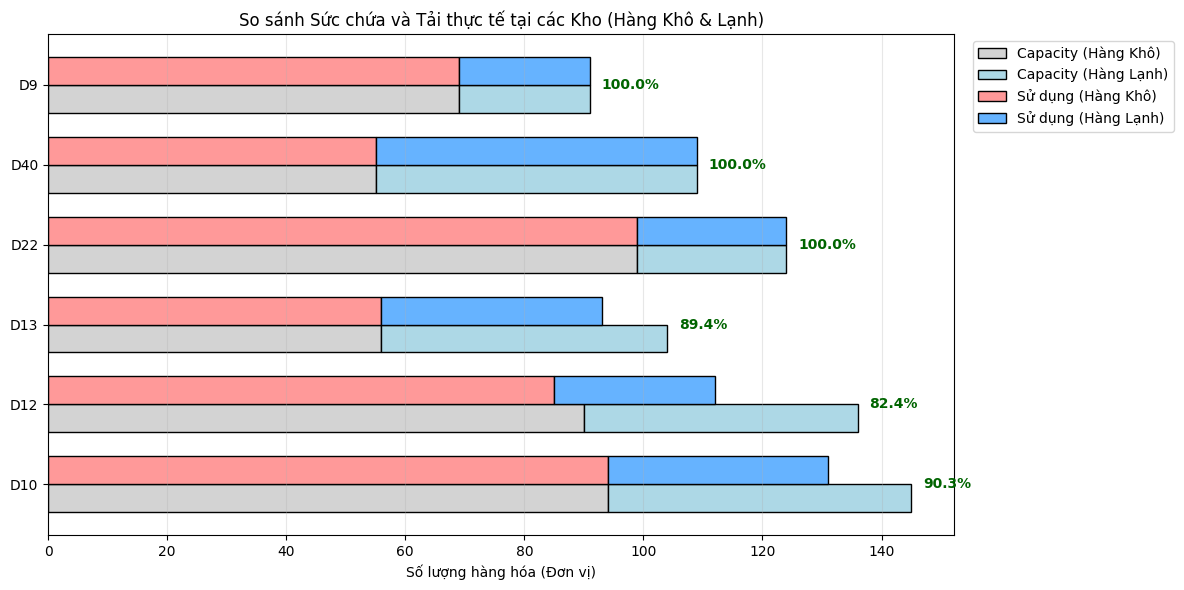

In [28]:
# 10. BIỂU ĐỒ STACKED BAR: CAPACITY VS SỬ DỤNG
# =========================

plot_df = depot_summary_df.sort_values("depot_id").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, max(6, 0.6 * len(plot_df))))
y_pos = np.arange(len(plot_df))
bar_height = 0.35

# Vẽ Capacity Bar 
ax.barh(y_pos - bar_height/2, plot_df["capacity_Dry"], height=bar_height, 
        label="Capacity (Hàng Khô)", color="#d3d3d3", edgecolor="black")
ax.barh(y_pos - bar_height/2, plot_df["capacity_Cold"], height=bar_height, 
        left=plot_df["capacity_Dry"], label="Capacity (Hàng Lạnh)", color="#add8e6", edgecolor="black")

# Vẽ Used Bar 
ax.barh(y_pos + bar_height/2, plot_df["used_Dry"], height=bar_height, 
        label="Sử dụng (Hàng Khô)", color="#ff9999", edgecolor="black")
ax.barh(y_pos + bar_height/2, plot_df["used_Cold"], height=bar_height, 
        left=plot_df["used_Dry"], label="Sử dụng (Hàng Lạnh)", color="#66b3ff", edgecolor="black")

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["depot_id"])
ax.set_xlabel("Số lượng hàng hóa (Đơn vị)")
ax.set_title("So sánh Sức chứa và Tải thực tế tại các Kho (Hàng Khô & Lạnh)")
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
ax.grid(axis="x", alpha=0.3)

# % utilization
for idx, row in plot_df.iterrows():
    ax.text(
        row["total_capacity"] + 2, 
        idx, 
        f"{row['utilization_rate']:.1%}", 
        va="center", fontsize=10, fontweight="bold", color="darkgreen"
    )

plt.tight_layout()
plt.show()

### 10.1 Suggestion 


BÁO CÁO CHẨN ĐOÁN VÀ ĐỀ XUẤT VẬN HÀNH (CAPACITY RIGHTSIZING)

📍 Kho D10 (Hiệu suất: 90.3% | Chi phí cố định: 155)
  - 🚨 Quá tải: Mất buffer an toàn. Cần xem xét thuê thêm kho vệ tinh (Satellite facility).

📍 Kho D22 (Hiệu suất: 100.0% | Chi phí cố định: 138)
  - 🚨 Quá tải: Mất buffer an toàn. Cần xem xét thuê thêm kho vệ tinh (Satellite facility).

📍 Kho D12 (Hiệu suất: 82.4% | Chi phí cố định: 106)
  - ✅ Tối ưu: Đang hoạt động ở dải công suất hiệu quả nhất (Sweet spot).

📍 Kho D40 (Hiệu suất: 100.0% | Chi phí cố định: 107)
  - 🚨 Quá tải: Mất buffer an toàn. Cần xem xét thuê thêm kho vệ tinh (Satellite facility).

📍 Kho D13 (Hiệu suất: 89.4% | Chi phí cố định: 102)
  - ✅ Tối ưu: Đang hoạt động ở dải công suất hiệu quả nhất (Sweet spot).

📍 Kho D9 (Hiệu suất: 100.0% | Chi phí cố định: 113)
  - 🚨 Quá tải: Mất buffer an toàn. Cần xem xét thuê thêm kho vệ tinh (Satellite facility).



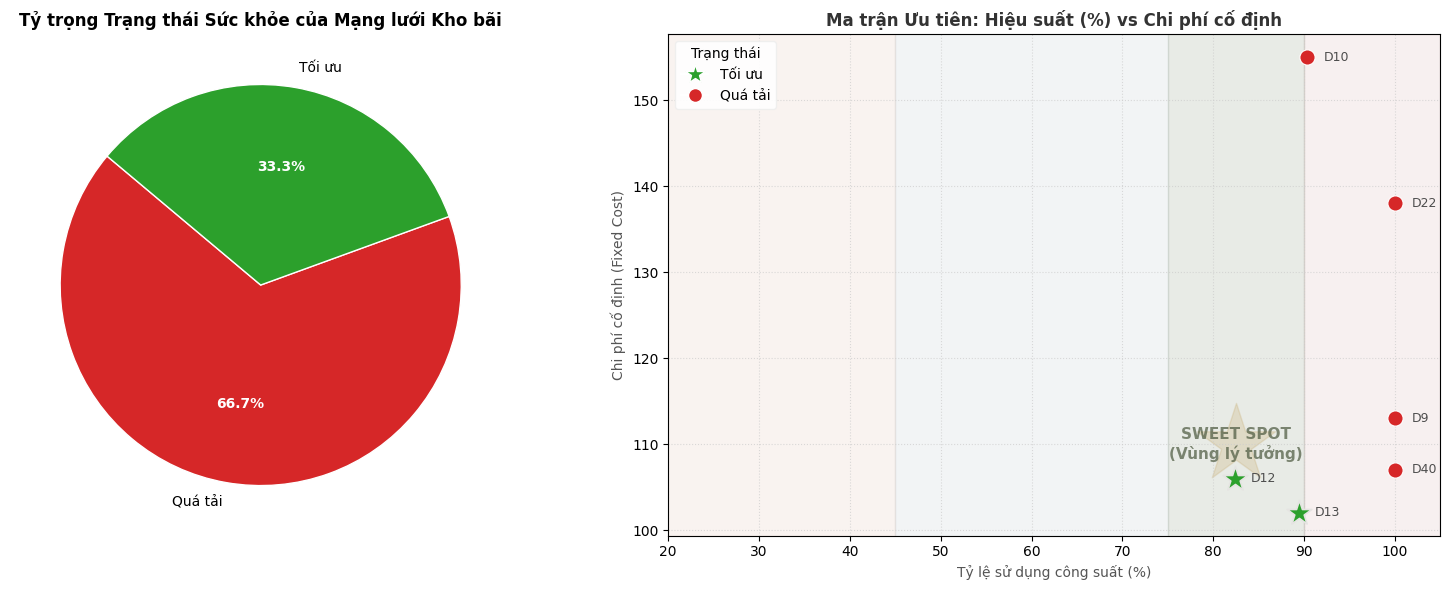

In [33]:
# 10.2. PHÂN TÍCH CHẨN ĐOÁN (DIAGNOSTIC TEXT)
# ---------------------------------------------------------
print("\n" + "="*70)
print("BÁO CÁO CHẨN ĐOÁN VÀ ĐỀ XUẤT VẬN HÀNH (CAPACITY RIGHTSIZING)")
print("="*70)

statuses = []

for _, row in depot_summary_df.iterrows():
    depot = row['depot_id']
    utilization = row['utilization_rate']
    cold_utilization = row['used_Cold'] / row['capacity_Cold'] if row['capacity_Cold'] > 0 else 0
    dry_utilization = row['used_Dry'] / row['capacity_Dry'] if row['capacity_Dry'] > 0 else 0
    
    suggestions = []
    status_label = "Bình thường"
    
    # Phân loại trạng thái tổng thể
    if utilization < 0.45:
        status_label = "Dưới công suất"
        suggestions.append("⚠️ Dưới công suất: Ưu tiên sáp nhập (Consolidation) luồng hàng sang kho lân cận để cắt giảm Fixed Cost.")
    elif utilization > 0.90:
        status_label = "Quá tải"
        suggestions.append("🚨 Quá tải: Mất buffer an toàn. Cần xem xét thuê thêm kho vệ tinh (Satellite facility).")
    elif 0.75 <= utilization <= 0.90:
        status_label = "Tối ưu"
        suggestions.append("✅ Tối ưu: Đang hoạt động ở dải công suất hiệu quả nhất (Sweet spot).")
        
    # Đánh giá lệch pha sản phẩm
    if row['capacity_Cold'] > 0 and cold_utilization == 0:
        suggestions.append("❄️ Lãng phí năng lượng: Kho lạnh trống hoàn toàn. Đề xuất tắt hệ thống lạnh hoặc chuyển đổi công năng.")
    elif cold_utilization > 0.95 and dry_utilization < 0.5:
        suggestions.append("🔄 Lệch pha: Kho lạnh đầy, kho khô trống. Cân nhắc cải tạo vách ngăn để tăng diện tích làm mát.")

    statuses.append(status_label)

    # In kết quả Text
    print(f"\n📍 Kho {depot} (Hiệu suất: {utilization:.1%} | Chi phí cố định: {row['fixed_cost']})")
    if not suggestions:
        print("  - Trạng thái vận hành ổn định.")
    else:
        for s in suggestions:
            print(f"  - {s}")

print("\n" + "="*70)

depot_summary_df["status_label"] = statuses

# ---------------------------------------------------------
# 10.3. DASHBOARD TRỰC QUAN HÓA CHIẾN LƯỢC
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Biểu đồ 1: Donut Chart thống kê sức khỏe mạng lưới ---
status_counts = depot_summary_df["status_label"].value_counts()
colors_map = {"Tối ưu": "#2ca02c", "Bình thường": "#1f77b4", "Dưới công suất": "#ff7f0e", "Quá tải": "#d62728"}
pie_colors = [colors_map.get(lbl, "#333333") for lbl in status_counts.index]

wedges, texts, autotexts = ax1.pie(
    status_counts, labels=status_counts.index, autopct='%1.1f%%',
    startangle=140, colors=pie_colors, wedgeprops=dict(width=1, edgecolor='white')
)
ax1.set_title("Tỷ trọng Trạng thái Sức khỏe của Mạng lưới Kho bãi", fontweight="bold")
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# --- Biểu đồ 2: Ma trận Vận hành (Scatter Plot: Hiệu suất vs Chi phí) ---
x_data = depot_summary_df["utilization_rate"] * 100
y_data = depot_summary_df["fixed_cost"]

# Vẽ các vùng cảnh báo (Background Spans - Dùng tone pastel cực nhạt)
ax2.axvspan(0, 45, color='#B66D46', alpha=0.08)
ax2.axvspan(45, 75, color='#637A8C', alpha=0.08)
ax2.axvspan(75, 90, color='#6A7B58', alpha=0.15) # Nhấn đậm hơn xíu ở vùng lý tưởng
ax2.axvspan(90, 105, color='#9B4444', alpha=0.08)

# Thêm Icon Ngôi sao và Text chìm cho vùng "Sweet Spot"
mid_y = y_data.median() if not y_data.empty else 150
ax2.scatter([82.5], [mid_y], marker='*', s=3500, color='#C5A869', alpha=0.25, zorder=1)
ax2.text(82.5, mid_y, "SWEET SPOT\n(Vùng lý tưởng)", color="#4A573D", 
         fontsize=11, fontweight="bold", ha="center", va="center", zorder=2, alpha=0.7)

# Vẽ từng điểm dữ liệu (Phân loại Marker)
for i, row in depot_summary_df.iterrows():
    status = row["status_label"]
    m_color = colors_map.get(status, "#333333")
    
    # Nếu là Tối ưu -> Vẽ Ngôi sao lớn, ngược lại vẽ Hình tròn
    if status == "Tối ưu":
        ax2.scatter(row["utilization_rate"] * 100, row["fixed_cost"], 
                    color=m_color, marker='*', s=350, edgecolor="#E5E4E2", linewidth=1.2, zorder=4)
    else:
        ax2.scatter(row["utilization_rate"] * 100, row["fixed_cost"], 
                    color=m_color, marker='o', s=120, edgecolor="white", linewidth=0.8, zorder=3)
        
    # Gắn nhãn tên kho
    ax2.annotate(row["depot_id"], (row["utilization_rate"] * 100 + 1.8, row["fixed_cost"]), 
                 fontsize=9, va='center', color="#4d4d4d", fontweight="500")

# Setup trục và lưới
ax2.set_xlim(min(20, x_data.min()-5), 105)
ax2.set_title("Ma trận Ưu tiên: Hiệu suất (%) vs Chi phí cố định", fontweight="bold", color="#333333")
ax2.set_xlabel("Tỷ lệ sử dụng công suất (%)", color="#555555")
ax2.set_ylabel("Chi phí cố định (Fixed Cost)", color="#555555")
ax2.grid(True, linestyle=":", alpha=0.7, color="#cccccc", zorder=0)

# Chú giải (Legend) tùy chỉnh
handles = [
    plt.Line2D([0], [0], marker='*' if label == "Tối ưu" else 'o', color='w', 
               markerfacecolor=color, markersize=15 if label == "Tối ưu" else 10, label=label) 
    for label, color in colors_map.items() if label in status_counts.index
]
ax2.legend(handles=handles, title="Trạng thái", loc="upper left", framealpha=0.9, edgecolor="#eeeeee")

plt.tight_layout()
plt.show()